In [1]:
import kan 
import torch
import matplotlib.pyplot as plt

f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = kan.utils.create_dataset(f, n_var=2)

checkpoint directory created: ./model
saving model version 0.0


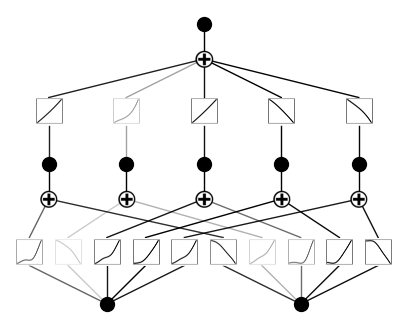

In [2]:
# 2 inputs, 5 hidden, 1 output, 3 drig intervals, cubic splines
model = kan.KAN(width=[2, 5, 1], grid=3, k=3, seed=42)

model(dataset['train_input'])
model.plot()
plt.show()

| train_loss: 1.42e-02 | test_loss: 1.46e-02 | reg: 6.14e+00 | : 100%|█| 50/50 [00:13<00:00,  3.68it


saving model version 0.1


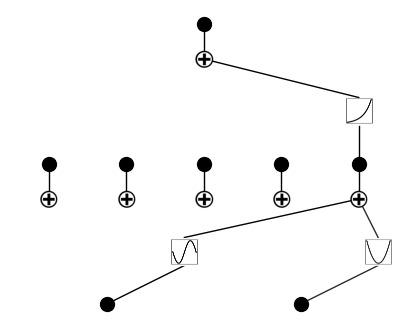

In [3]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001)
model.plot()
plt.show()

saving model version 0.2


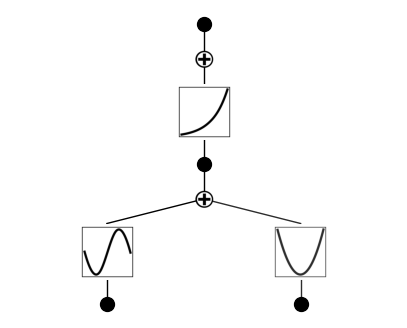

In [4]:
model = model.prune()
model.plot()
plt.show()

In [6]:
model = model.refine(10)
model.fit(dataset, opt="LBFGS", steps=50);  # ; suppresses outputs

saving model version 0.5


| train_loss: 4.65e-04 | test_loss: 4.84e-04 | reg: 7.62e+00 | : 100%|█| 50/50 [00:02<00:00, 17.16it

saving model version 0.6


In [ ]:
model.auto_symbolic()
model.fit(dataset, opt="LBFGS", steps=50)
from kan.utils import ex_round

import sympy as sp  # added after x1 not defined error (Ai)
x1, x2 = sp.symbols('x_1 x_2')  # added after x1 not defined error (Ai)
# print(kan.utils.ex_round(model.symbolic_formula(var=[x1, x2])[0][0], 2))  # 'var=[x1, x2]' added after x1 not defined error (Ai) NOTE this is for NON-notebooks
ex_round(model.symbolic_formula(var=[x1, x2])[0][0], 2)  # 'var=[x1, x2]' added after x1 not defined error (Ai)
# this seems to run smoother in Google Colabs sometimes

skipping (0,0,0) since already symbolic
skipping (0,1,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.25


| train_loss: 6.36e-05 | test_loss: 6.51e-05 | reg: 0.00e+00 | : 100%|█| 50/50 [00:02<00:00, 18.66it


saving model version 0.26


1.0*exp(0.920087615219449*x_2**2 + 1.0*sin(3.14*x_1))